<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Adaboost_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [8]:
# Dataset Breast Cancer Wisconsin

data = load_breast_cancer()
X, y = data.data, data.target

# Reducir a 2D para visualización
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

In [9]:
# Malla para frontera

xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 300),
    np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 300)
)

In [10]:
# Iteraciones a mostrar

stages = [1, 2, 4, 8, 16, 32]
accuracies = []

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3)

In [11]:
# Fronteras de decisión
for i, n_estimators in enumerate(stages):
    ax = fig.add_subplot(gs[i // 3, i % 3])

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators,
        learning_rate=1,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predicción para frontera
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35)
    ax.scatter(
        X_train[:,0],
        X_train[:,1],
        c=y_train,
        edgecolor="black",
        s=35
    )

    ax.set_title(f"Weak Learners = {n_estimators}", weight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

    # Accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

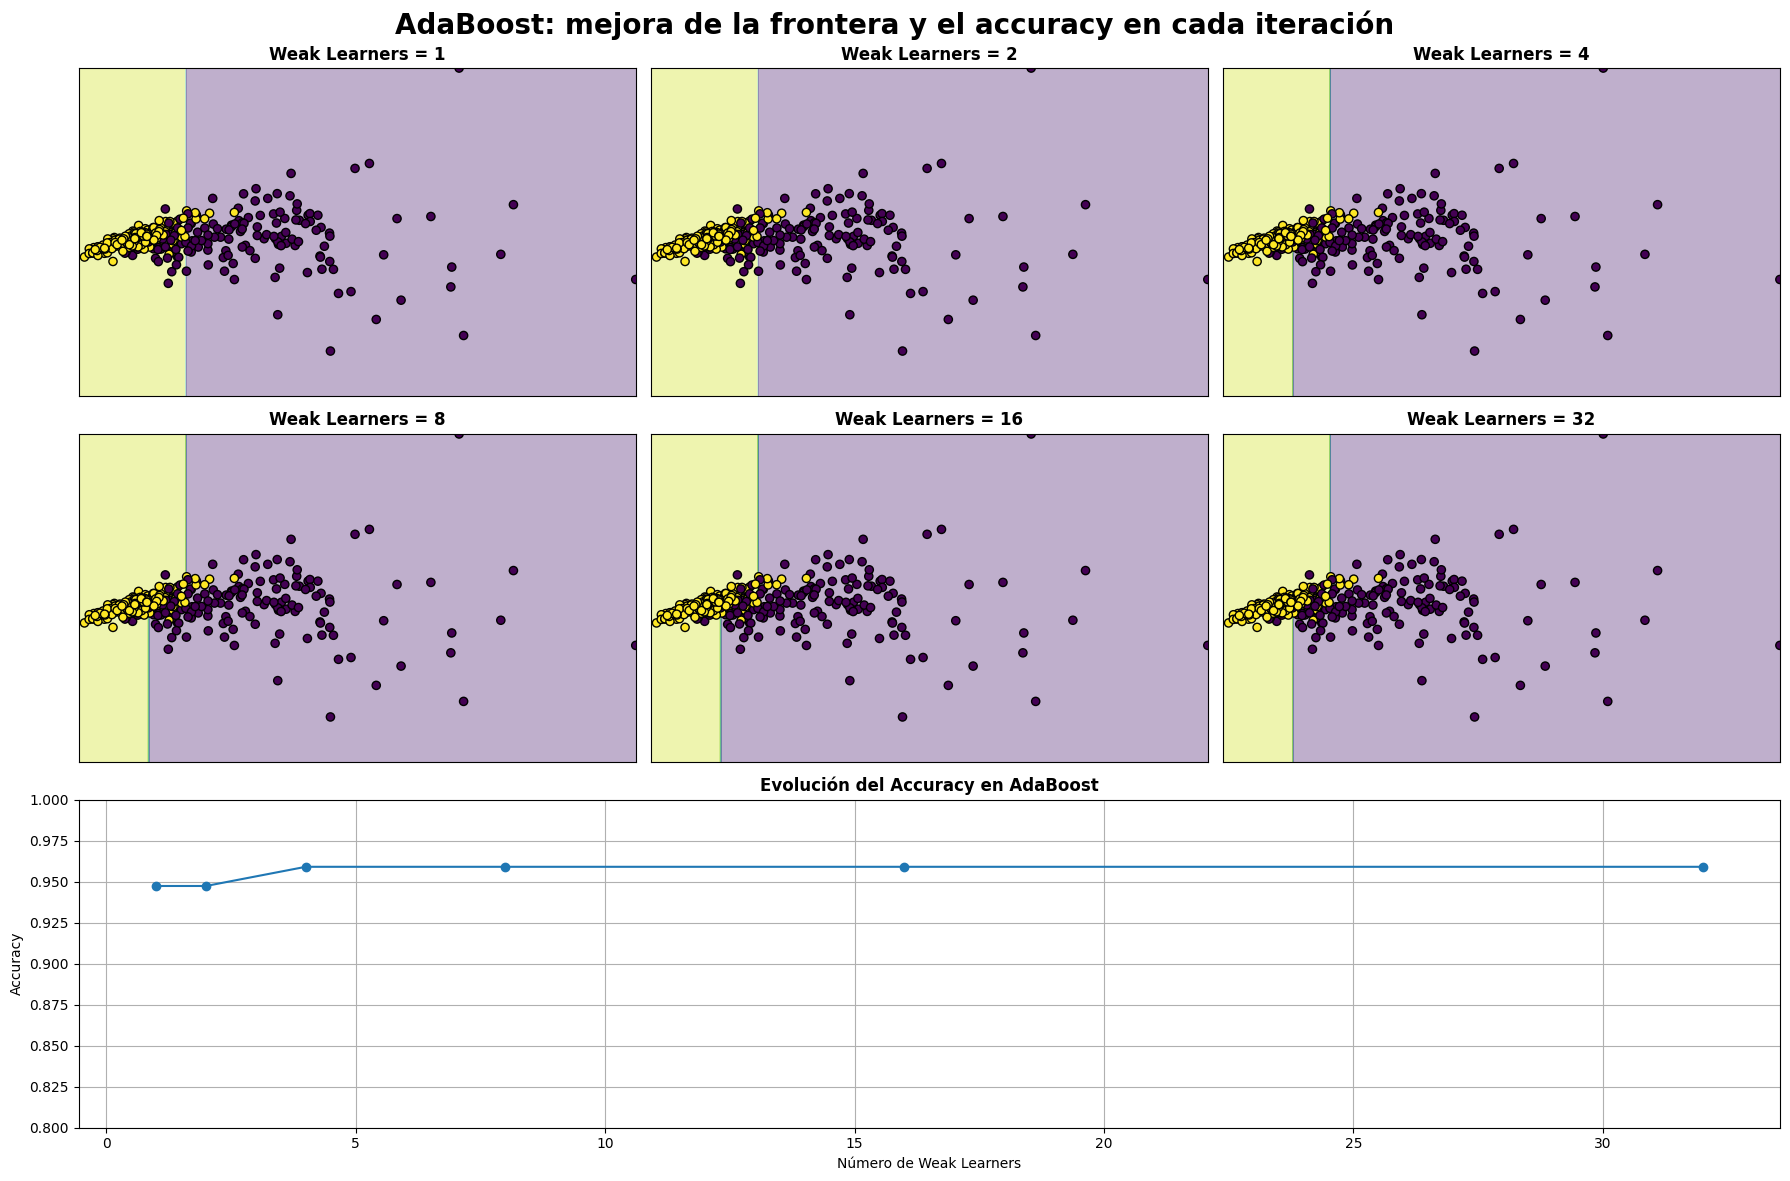

In [12]:
# Accuracy vs Iteraciones

ax_acc = fig.add_subplot(gs[2, :])
ax_acc.plot(stages, accuracies, marker='o')
ax_acc.set_xlabel("Número de Weak Learners")
ax_acc.set_ylabel("Accuracy")
ax_acc.set_title("Evolución del Accuracy en AdaBoost", weight="bold")
ax_acc.set_ylim(0.8, 1.0)
ax_acc.grid(True)

plt.suptitle(
    "AdaBoost: mejora de la frontera y el accuracy en cada iteración",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# ADABOOST VIDEO: FRONTERA + ACCURACY
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.animation import FuncAnimation, FFMpegWriter

# -----------------------------
# Dataset
# -----------------------------
data = load_breast_cancer()
X, y = data.data, data.target

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

# -----------------------------
# Malla
# -----------------------------
xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 300),
    np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 300)
)

# -----------------------------
# Configuración
# -----------------------------
max_estimators = 25
accuracies = [] # This list will accumulate accuracies over frames

fig, (ax_dec, ax_acc) = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    global accuracies # Declare intent to modify the global 'accuracies' list
    if frame == 0:
        accuracies.clear() # Clear the list at the very start of a new animation run

    ax_dec.clear()
    ax_acc.clear()

    n_estimators = frame + 1

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators,
        learning_rate=1,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Accuracy
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

    # Frontera
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax_dec.contourf(xx, yy, Z, alpha=0.35)
    ax_dec.scatter(
        X_train[:,0], X_train[:,1],
        c=y_train, edgecolor="black", s=30
    )
    ax_dec.set_title(f"Frontera de decisión (Iteración {n_estimators})")
    ax_dec.set_xticks([])
    ax_dec.set_yticks([])

    # Accuracy plot
    ax_acc.plot(range(1, n_estimators + 1), accuracies, marker="o")
    ax_acc.set_ylim(0.8, 1.0)
    ax_acc.set_xlabel("Iteraciones")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title("Evolución del Accuracy")
    ax_acc.grid(True)

ani = FuncAnimation(fig, update, frames=max_estimators, interval=500)

# -----------------------------
# Guardar video
# -----------------------------
output_path = "/content/adaboost_frontera_accuracy.mp4" # Changed path to /content/
writer = FFMpegWriter(fps=2, bitrate=1800)
ani.save(output_path, writer=writer)

plt.close()

output_path